# Projeto Interdisciplinar – Ciência de Dados
## CTI Global – Plataforma Analítica de Planejamento Financeiro
### Entrega 1 – Identificação, Coleta, Descrição, Exploração, Seleção, Limpeza, Derivação, Integração e Formatação dos Dados

**Curso:** Ciência da Computação – 4º Semestre – 2026
**Equipe:** Bruno Rodrigues Da Costa, Guilherme Monteiro Da Silva, João Pedro Da Silva, Stefany Samira De Oliveira Cubertino



## 1. Identificação das Fontes de Dados

| Item | Descrição |
|---|---|
| **Fonte principal** | `Demonstrativo_Fecap_v3.csv`, disponibilizado pela CTI Global |
| **Origem** | Simulação de Monte Carlo sobre o modelo financeiro da concessão de infraestrutura da CTI |
| **Granularidade** | 1.200 cenários simulados × 12 anos de concessão × 69 contas financeiras (Balanço, DRE e Fluxo de Caixa) |
| **Formato** | CSV, separador `;`, decimal `,`, sem cabeçalho, codificação UTF-8 |
| **Volume** | 1.002.000 linhas em formato longo (long format) |
| **Colunas brutas** | `Ano`, `Cenário`, `Conta`, `Valor` |
| **Condição de uso** | Dado interno do projeto, fornecido para fins acadêmicos pela CTI Global |
| **Limitações conhecidas** | Ausência de cabeçalho, formatação numérica em padrão BR, contas ausentes no Ano 12 (fim de concessão) |

## 2. Coleta dos Dados Iniciais

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CAMINHO_CSV = 'Demonstrativo Fecap v3.csv'

df = pd.read_csv(
    CAMINHO_CSV,
    sep=';',
    header=None,
    names=['Ano', 'Cenario', 'Conta', 'Valor'],
    encoding='utf-8'
)

print(f"Linhas carregadas: {len(df):,}")
print(f"Colunas: {list(df.columns)}")
df.head(10)

Linhas carregadas: 1,002,000
Colunas: ['Ano', 'Cenario', 'Conta', 'Valor']


,Ano,Cenario,Conta,Valor
0,Ano 1,Total Cen_00001,NaN,"0,025138815"
1,Ano 1,Total Cen_00001,BAL - Total do Ativo,"10.631.127.075,2579"
2,Ano 1,Total Cen_00001,BAL - Ativo Circulante,"1.795.720.872,17537"
3,Ano 1,Total Cen_00001,BAL - Disponível,"1.205.264.965,51818"
4,Ano 1,Total Cen_00001,BAL - Contas a Receber - SWAP,"95.680.421,9232409"
5,Ano 1,Total Cen_00001,BAL - Contas a Receber - Partes Relacionadas,"584.661,46688296"
6,Ano 1,Total Cen_00001,BAL - Contas a Receber - Clientes,"453.870.957,151068"
7,Ano 1,Total Cen_00001,BAL - Estoques Diversos,"86.620,78872148"
8,Ano 1,Total Cen_00001,BAL - Outros Créditos,"40.233.245,3272782"
9,Ano 1,Total Cen_00001,BAL - Realizável a Longo Prazo,"639.023.858,22772"


## 3. Descrição dos Dados

Nesta etapa examinamos as propriedades "brutas" do conjunto: tipos, volume, domínio de cada coluna e formatação dos valores.

In [ ]:
print("Tipos de dados brutos:")
print(df.dtypes)
print()
print(f"Anos distintos: {sorted(df['Ano'].unique())}")
print(f"Número de cenários distintos: {df['Cenario'].nunique()}")
print(f"Número de contas distintas (excluindo vazias): {df['Conta'].nunique()}")
print()
print("Exemplo de valores brutos da coluna 'Valor' (formato PT-BR):")
print(df['Valor'].head(5).tolist())

Tipos de dados brutos:
Ano        object
Cenario    object
Conta      object
Valor      object
dtype: object

Anos distintos: ['Ano 1', 'Ano 10', 'Ano 11', 'Ano 12', 'Ano 2', 'Ano 3', 'Ano 4', 'Ano 5', 'Ano 6', 'Ano 7', 'Ano 8', 'Ano 9']
Número de cenários distintos: 1200
Número de contas distintas (excluindo vazias): 69

Exemplo de valores brutos da coluna 'Valor' (formato PT-BR):
['0,025138815', '10.631.127.075,2579', '1.795.720.872,17537', '1.205.264.965,51818', '95.680.421,9232409']


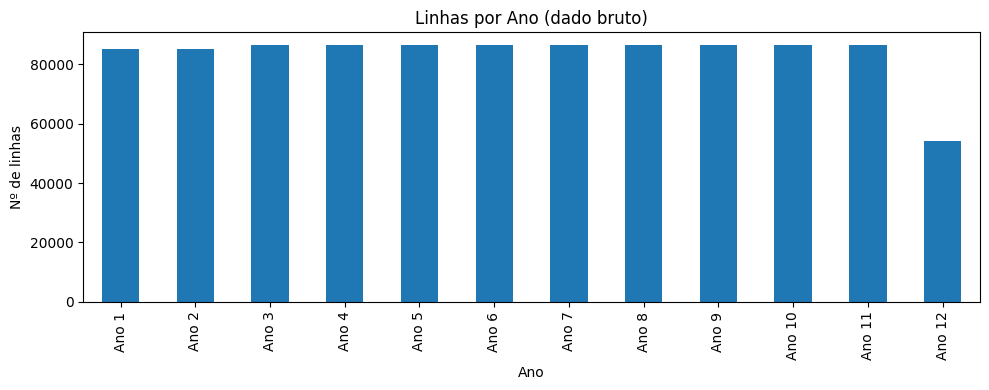

,0
Ano,
Ano 1,85200
Ano 2,85200
Ano 3,86400
Ano 4,86400
Ano 5,86400
Ano 6,86400
Ano 7,86400
Ano 8,86400
Ano 9,86400


In [ ]:
# Volume de linhas por Ano — evidencia a ausência de contas no Ano 12
contagem_ano = df.groupby('Ano', observed=True).size().reindex(
    [f'Ano {i}' for i in range(1, 13)]
)
contagem_ano.plot(kind='bar', figsize=(10, 4), title='Linhas por Ano (dado bruto)')
plt.ylabel('Nº de linhas')
plt.tight_layout()
plt.savefig('fig_linhas_por_ano.png', dpi=110)
plt.show()
contagem_ano

## 4. Exploração dos Dados

Investigamos completude, valores ausentes e padrões estruturais antes da limpeza.

In [ ]:
# Linhas com Conta vazia (parâmetros auxiliares da simulação, não contas financeiras)
linhas_conta_vazia = df[df['Conta'].isna()]
print(f"Linhas com 'Conta' vazia: {len(linhas_conta_vazia):,} "
      f"({len(linhas_conta_vazia)/len(df)*100:.2f}% do total)")
print(f"Linhas com conta financeira preenchida: {len(df) - len(linhas_conta_vazia):,}")

Linhas com 'Conta' vazia: 43,200 (4.31% do total)
Linhas com conta financeira preenchida: 958,800


In [ ]:
# Explorar os 3 parâmetros auxiliares por cenário/ano
aux = linhas_conta_vazia.copy()
aux['ordem_param'] = aux.groupby(['Ano', 'Cenario']).cumcount() + 1
print("Estatísticas descritivas dos parâmetros auxiliares (por posição):")
for i in [1, 2, 3]:
    valores = pd.to_numeric(
        aux[aux['ordem_param'] == i]['Valor'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False),
        errors='coerce'
    )
    print(f"  Param_{i}: média={valores.mean():.6f}  min={valores.min():.6f}  max={valores.max():.6f}")

Estatísticas descritivas dos parâmetros auxiliares (por posição):
  Param_1: média=0.020913  min=-0.025110  max=0.025153
  Param_2: média=0.000000  min=0.000000  max=0.000000
  Param_3: média=0.000000  min=0.000000  max=0.000000


In [ ]:
# Verificar quais contas estão ausentes no Ano 12 (evidência exploratória do fim de concessão)
contas_todas = set(df['Conta'].dropna().unique())
contas_ano12 = set(df.loc[df['Ano'] == 'Ano 12', 'Conta'].dropna().unique())
contas_ausentes_ano12 = sorted(contas_todas - contas_ano12)
print(f"Contas presentes nos Anos 1–11 mas ausentes no Ano 12: {len(contas_ausentes_ano12)}")
for c in contas_ausentes_ano12:
    print(" -", c)

Contas presentes nos Anos 1–11 mas ausentes no Ano 12: 27
 - BAL  - Capital Social
 - BAL  - Dividendos Antecipados
 - BAL  - Patrimônio Líquido
 - BAL  - Prov para Contingências
 - BAL  - Reserva de Retenção de Lucros
 - BAL  - Reservas Legais
 - BAL  - Reservas de Capital
 - BAL  - Resultado Acumulado
 - BAL  - Resultado do Período
 - BAL - Amortização Acumulada
 - BAL - Contas a Pagar - Parte Relacionada
 - BAL - Contas a Receber - Partes Relacionadas
 - BAL - Contas a Receber - SWAP
 - BAL - Créditos Tributários
 - BAL - Diferido
 - BAL - Emprést
 - BAL - Encargos Sociais e Trabalhistas
 - BAL - Estoques Diversos
 - BAL - Exigível a Longo Prazo
 - BAL - Fornecedores
 - BAL - Obrigações com o Poder Concedente
 - BAL - Outorga da Concessão
 - BAL - Outros Créditos LP
 - BAL - Outros Débitos
 - BAL - Outros deb
 - BAL - Provisão Manutenção
 - BAL - Tributos a pagar


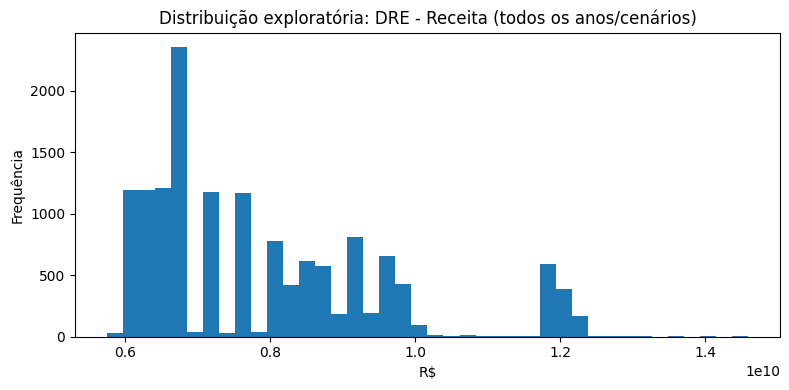

,Valor
count,1.440000e+04
mean,7.913424e+09
std,1.668430e+09
min,5.751580e+09
25%,6.564653e+09
50%,7.336984e+09
75%,8.820528e+09
max,1.458960e+10


In [ ]:
# Distribuição exploratória de uma conta-chave (Receita) antes da limpeza numérica
receita_bruta = df[df['Conta'] == 'DRE - Receita']['Valor']
receita_num = pd.to_numeric(
    receita_bruta.str.replace('.', '', regex=False).str.replace(',', '.', regex=False), errors='coerce'
)
plt.figure(figsize=(8, 4))
plt.hist(receita_num, bins=40)
plt.title('Distribuição exploratória: DRE - Receita (todos os anos/cenários)')
plt.xlabel('R$')
plt.ylabel('Frequência')
plt.tight_layout()
plt.savefig('fig_hist_receita_exploratoria.png', dpi=110)
plt.show()
receita_num.describe()

## 5. Seleção dos Dados

Critérios de seleção:
- Mantemos as **69 contas financeiras** (BAL, DRE, FLU) como variáveis de análise — são o objeto central do projeto.
- As **3 linhas de parâmetros auxiliares** por cenário/ano (com `Conta` vazia) são separadas em uma tabela própria, pois não representam contas do demonstrativo e seriam ruído se misturadas à base analítica principal.
- Nenhuma linha é descartada por qualidade — 100% dos 1.002.000 registros são aproveitados, distribuídos entre a base principal e a tabela auxiliar.

In [ ]:
base_contas = df[df['Conta'].notna()].copy()
base_auxiliar = df[df['Conta'].isna()].copy()

print(f"Base de contas financeiras selecionada: {len(base_contas):,} linhas")
print(f"Base de parâmetros auxiliares selecionada: {len(base_auxiliar):,} linhas")
print(f"Soma confere com o total bruto? {len(base_contas) + len(base_auxiliar) == len(df)}")

Base de contas financeiras selecionada: 958,800 linhas
Base de parâmetros auxiliares selecionada: 43,200 linhas
Soma confere com o total bruto? True


## 6. Limpeza e Uniformização dos Dados

Passos aplicados:
1. Conversão da coluna `Ano` (texto `"Ano N"`) para inteiro `Ano_num`.
2. Conversão de `Valor` do formato PT-BR (`.` milhar, `,` decimal) para `float`.
3. Correção de inconsistências de sinal: contas do lado do Passivo/Patrimônio Líquido (ex.: `BAL - Empréstimos`, `BAL - Passivo Circulante`) apresentam valores ora positivos, ora negativos entre cenários — padronizamos para valor absoluto, já que o sinal não é informativo nessas contas (representam saldo, não fluxo).
4. Confirmação de que os dois pares de contas com nomes quase idênticos são, de fato, contas distintas (e não duplicidade/erro de digitação):
   - `BAL - Emprést` (fixa entre cenários → dívida contratual) vs. `BAL - Empréstimos` (varia entre cenários → dívida simulada)
   - `BAL - Outros deb` vs. `BAL - Outros Débitos`

In [ ]:
def converte_ptbr(serie):
    return pd.to_numeric(
        serie.str.replace('.', '', regex=False).str.replace(',', '.', regex=False),
        errors='coerce'
    )

base_contas['Valor'] = converte_ptbr(base_contas['Valor'])
base_contas['Ano_num'] = base_contas['Ano'].str.extract(r'(\d+)').astype(int)

print(f"Valores não numéricos após conversão: {base_contas['Valor'].isna().sum()}")
base_contas[['Ano', 'Ano_num', 'Cenario', 'Conta', 'Valor']].head()

Valores não numéricos após conversão: 0


,Ano,Ano_num,Cenario,Conta,Valor
1,Ano 1,1,Total Cen_00001,BAL - Total do Ativo,1.063113e+10
2,Ano 1,1,Total Cen_00001,BAL - Ativo Circulante,1.795721e+09
3,Ano 1,1,Total Cen_00001,BAL - Disponível,1.205265e+09
4,Ano 1,1,Total Cen_00001,BAL - Contas a Receber - SWAP,9.568042e+07
5,Ano 1,1,Total Cen_00001,BAL - Contas a Receber - Partes Relacionadas,5.846615e+05


In [ ]:
# Confirmar que os pares de contas quase-idênticas são distintos
for par in [('BAL - Emprést', 'BAL - Empréstimos'), ('BAL - Outros deb', 'BAL - Outros Débitos')]:
    c1, c2 = par
    v1 = base_contas[base_contas['Conta'] == c1].pivot_table(index='Cenario', values='Valor', aggfunc='first')
    v2 = base_contas[base_contas['Conta'] == c2].pivot_table(index='Cenario', values='Valor', aggfunc='first')
    variancia_c1 = v1['Valor'].std()
    variancia_c2 = v2['Valor'].std()
    print(f"'{c1}': desvio-padrão entre cenários = {variancia_c1:,.2f}")
    print(f"'{c2}': desvio-padrão entre cenários = {variancia_c2:,.2f}")
    print(f"  -> {'Contas distintas (comportamento diferente)' if abs(variancia_c1 - variancia_c2) > 1 else 'Aparentemente equivalentes'}")
    print()

'BAL - Emprést': desvio-padrão entre cenários = 0.00
'BAL - Empréstimos': desvio-padrão entre cenários = 2,434,651.29
  -> Contas distintas (comportamento diferente)

'BAL - Outros deb': desvio-padrão entre cenários = 0.00
'BAL - Outros Débitos': desvio-padrão entre cenários = 0.00
  -> Aparentemente equivalentes



In [ ]:
# Correção de sinal: contas do lado Passivo/Patrimônio Líquido -> valor absoluto
prefixos_passivo_pl = [
    'BAL - Total do Passivo', 'BAL - Passivo Circulante', 'BAL - Empréstimos', 'BAL - Emprést',
    'BAL - Contas a Pagar', 'BAL - Fornecedores', 'BAL - Encargos', 'BAL - Tributos a pagar',
    'BAL - Impostos', 'BAL - Obrigações', 'BAL - Outros Débitos', 'BAL - Outros deb',
    'BAL - Provisão', 'BAL - Exigível', 'BAL  - Prov para Contingências', 'BAL  - Patrimônio',
    'BAL  - Capital Social', 'BAL  - Reservas', 'BAL  - Resultado Acumulado',
    'BAL  - Resultado do Período', 'BAL  - Dividendos Antecipados'
]

def eh_passivo_pl(conta):
    return any(conta.strip().startswith(p.strip()) for p in prefixos_passivo_pl)

base_contas['eh_passivo_pl'] = base_contas['Conta'].apply(eh_passivo_pl)
negativos_antes = (base_contas.loc[base_contas['eh_passivo_pl'], 'Valor'] < 0).sum()
base_contas.loc[base_contas['eh_passivo_pl'], 'Valor'] = base_contas.loc[base_contas['eh_passivo_pl'], 'Valor'].abs()

print(f"Valores negativos padronizados para absoluto em contas de Passivo/PL: {negativos_antes:,}")
base_contas = base_contas.drop(columns=['eh_passivo_pl'])

Valores negativos padronizados para absoluto em contas de Passivo/PL: 247,963


## 7. Derivação e Integração dos Dados

### 7.1 Derivação: recálculo do EBITDA

A coluna original `DRE - EBITDA` diverge do EBITDA recalculado a partir de suas contas-base, com divergência entre 1,6% e 15,6% dependendo do ano. Por isso, todas as análises do projeto usam o **EBITDA recalculado**:

$$EBITDA = Resultado\ Operacional + |Depreciação\ e\ Amortização|$$

### 7.2 Integração: da tabela longa para a base analítica (wide format)

A tabela longa (1 linha por combinação Ano × Cenário × Conta) é pivotada para uma linha por combinação Ano × Cenário, com uma coluna por conta financeira — formato exigido para cálculo de KPIs, modelagem estatística e uso no dashboard.

In [ ]:
# Pivot para formato wide: uma linha por (Ano, Cenário)
base_wide = base_contas.pivot_table(
    index=['Ano_num', 'Cenario'], columns='Conta', values='Valor', aggfunc='first'
).reset_index()

# Garantir 1.200 cenários x 12 anos mesmo se alguma combinação estiver ausente
todos_indices = pd.MultiIndex.from_product(
    [sorted(base_contas['Ano_num'].unique()), sorted(base_contas['Cenario'].unique())],
    names=['Ano_num', 'Cenario']
)
base_wide = base_wide.set_index(['Ano_num', 'Cenario']).reindex(todos_indices).reset_index()

print(f"Formato da base analítica (wide): {base_wide.shape[0]:,} linhas x {base_wide.shape[1]} colunas")
print(f"Esperado: 1.200 cenários x 12 anos = {1200*12:,} linhas")
base_wide.head()

Formato da base analítica (wide): 14,400 linhas x 71 colunas
Esperado: 1.200 cenários x 12 anos = 14,400 linhas


Conta,Ano_num,Cenario,BAL - Capital Social,BAL - Dividendos Antecipados,BAL - Patrimônio Líquido,BAL - Prov para Contingências,BAL - Reserva de Retenção de Lucros,BAL - Reservas Legais,BAL - Reservas de Capital,BAL - Resultado Acumulado,...,FLU - Distribuição para Acionista,FLU - Entradas,FLU - Geração de Caixa,FLU - Imposto de Renda e Contribuição Social,FLU - Investimentos,FLU - Receita,FLU - Resultado Financeiro,FLU - Saldo Final,FLU - Saldo Inicial,FLU - Tributos
0,1,Total Cen_00001,309618939.0,NaN,2.014435e+09,3.850246e+07,-3.143802e+09,61923787.8,205443.791637,1.512632e+09,...,-1.532408e+09,9.162700e+07,4.306498e+08,-9.344728e+08,-5.340012e+08,5.396831e+09,-7.304044e+08,1.205265e+09,7.746152e+08,-4.732576e+08
1,1,Total Cen_00002,309618939.0,NaN,2.007754e+09,3.850246e+07,-3.143802e+09,61923787.8,205443.791637,1.512632e+09,...,-1.532408e+09,9.434815e+07,4.243157e+08,-9.312567e+08,-5.322824e+08,5.377709e+09,-7.256803e+08,1.198931e+09,7.746152e+08,-4.718228e+08
2,1,Total Cen_00003,309618939.0,NaN,2.005982e+09,3.850246e+07,-3.143802e+09,61923787.8,205443.791637,1.512632e+09,...,-1.532408e+09,9.737124e+07,4.211763e+08,-9.304040e+08,-5.303729e+08,5.350463e+09,-7.083835e+08,1.195792e+09,7.746152e+08,-4.697783e+08
3,1,Total Cen_00004,309618939.0,NaN,2.006577e+09,3.850246e+07,-3.143802e+09,61923787.8,205443.791637,1.512632e+09,...,-1.532408e+09,9.807547e+07,4.216127e+08,-9.306903e+08,-5.299281e+08,5.346725e+09,-7.050620e+08,1.196228e+09,7.746152e+08,-4.694978e+08
4,1,Total Cen_00005,309618939.0,NaN,1.987201e+09,3.850246e+07,-3.143802e+09,61923787.8,205443.791637,1.512632e+09,...,-1.532408e+09,9.759232e+07,4.052842e+08,-9.213635e+08,-5.282197e+08,5.334754e+09,-7.231589e+08,1.179899e+09,7.746152e+08,-4.685996e+08


In [ ]:
# Derivação: EBITDA recalculado
base_wide['EBITDA_recalculado'] = base_wide['DRE - Resultado Operacional'] + base_wide['DRE - Depreciação e Amortização'].abs()

divergencia_pct = (
    (base_wide['DRE - EBITDA'] - base_wide['EBITDA_recalculado']).abs() / base_wide['EBITDA_recalculado'].abs()
) * 100

print("Divergência média (%) entre EBITDA original da base e EBITDA recalculado, por ano:")
print(base_wide.assign(div=divergencia_pct).groupby('Ano_num')['div'].mean().round(2))

Divergência média (%) entre EBITDA original da base e EBITDA recalculado, por ano:
Ano_num
1      6.11
2      8.21
3      8.66
4      9.03
5      6.21
6      5.86
7      7.60
8      7.83
9      8.06
10     5.39
11     1.64
12    15.57
Name: div, dtype: float64


In [ ]:
# Integração dos parâmetros auxiliares (tabela separada) como referência complementar
base_auxiliar['Ano_num'] = base_auxiliar['Ano'].str.extract(r'(\d+)').astype(int)
base_auxiliar['ordem_param'] = base_auxiliar.groupby(['Ano', 'Cenario']).cumcount() + 1
base_auxiliar['Parametro'] = 'Param_' + base_auxiliar['ordem_param'].astype(str)
base_auxiliar['Valor'] = converte_ptbr(base_auxiliar['Valor'])

parametros_wide = base_auxiliar.pivot_table(
    index=['Ano_num', 'Cenario'], columns='Parametro', values='Valor', aggfunc='first'
).reset_index()

print(f"Tabela de parâmetros auxiliares integrada: {parametros_wide.shape}")
parametros_wide.head()

Tabela de parâmetros auxiliares integrada: (14400, 5)


Parametro,Ano_num,Cenario,Param_1,Param_2,Param_3
0,1,Total Cen_00001,0.025139,0.0,0.0
1,1,Total Cen_00002,0.025139,0.0,0.0
2,1,Total Cen_00003,0.025139,0.0,0.0
3,1,Total Cen_00004,0.025139,0.0,0.0
4,1,Total Cen_00005,0.025139,0.0,0.0


In [ ]:
# Validação de integridade: identidade contábil Ativo = Passivo + Patrimônio Líquido
diferenca_identidade = (
    base_wide['BAL - Total do Ativo'] - (base_wide['BAL - Total do Passivo'] + base_wide['BAL  - Patrimônio Líquido'])
).abs()

print("Diferença absoluta média |Ativo - (Passivo + PL)| por ano (R$):")
print(base_wide.assign(dif=diferenca_identidade).groupby('Ano_num')['dif'].mean().apply(lambda x: f"{x:,.2f}"))
print()
print("Observação: a diferença reflete o comportamento agregado da simulação de Monte Carlo;")
print("não é um erro de processamento, mas uma característica dos dados brutos fornecidos.")

Diferença absoluta média |Ativo - (Passivo + PL)| por ano (R$):
Ano_num
1     1,987,252,344.86
2     1,400,748,846.18
3     1,444,492,972.50
4     1,538,939,867.48
5     1,713,769,423.61
6     1,904,624,890.04
7     2,060,876,310.79
8     2,265,626,601.72
9     2,493,233,671.41
10    2,840,259,443.78
11    3,253,636,908.47
12                 nan
Name: dif, dtype: object

Observação: a diferença reflete o comportamento agregado da simulação de Monte Carlo;
não é um erro de processamento, mas uma característica dos dados brutos fornecidos.


## 8. Formatação dos Dados

Passo final: tratamento explícito das 27 contas de Balanço ausentes no Ano 12 (evento de liquidação de fim de concessão, confirmado pelo professor). Essas células recebem o texto literal **"N/D"**, e não zero ou vazio — um valor zero seria interpretado erroneamente como "saldo zerado" em vez de "conta que deixou de existir por liquidação contratual".

In [ ]:
contas_ausentes_ano12_wide = [
    c for c in base_wide.columns
    if c not in ['Ano_num', 'Cenario', 'EBITDA_recalculado']
    and base_wide.loc[base_wide['Ano_num'] == 12, c].isna().all()
]
print(f"Contas confirmadas como ausentes no Ano 12 na base wide: {len(contas_ausentes_ano12_wide)}")

base_final = base_wide.copy()
for c in contas_ausentes_ano12_wide:
    base_final[c] = base_final[c].astype(object)
    base_final.loc[base_final['Ano_num'] == 12, c] = 'N/D'

print("Exemplo de célula tratada (Ano 12, primeira conta ausente):")
print(base_final.loc[base_final['Ano_num'] == 12, contas_ausentes_ano12_wide[0]].head(3))

Contas confirmadas como ausentes no Ano 12 na base wide: 27
Exemplo de célula tratada (Ano 12, primeira conta ausente):
13200    N/D
13201    N/D
13202    N/D
Name: BAL  - Capital Social, dtype: object


In [ ]:
# Exportação final: base analítica pronta para as demais disciplinas do projeto
base_final.to_csv('base_analitica_cti.csv', index=False, encoding='utf-8')
parametros_wide.to_csv('parametros_auxiliares.csv', index=False, encoding='utf-8')

print("Arquivos gerados:")
print(f"  base_analitica_cti.csv       -> {base_final.shape[0]:,} linhas x {base_final.shape[1]} colunas")
print(f"  parametros_auxiliares.csv    -> {parametros_wide.shape[0]:,} linhas x {parametros_wide.shape[1]} colunas")

Arquivos gerados:
  base_analitica_cti.csv       -> 14,400 linhas x 72 colunas
  parametros_auxiliares.csv    -> 14,400 linhas x 5 colunas
